In [1]:
from autolightning import auto_main

import yaml

configs = []

with open("./proto_net.yaml", "r") as f:
    proto_config = yaml.safe_load(f)
    configs.append(proto_config)

with open("./few_shot_data.yaml", "r") as f:
    data_config = yaml.safe_load(f)
    configs.append(data_config)

from metalarena.configs.machine_specific.lug import config
configs.append(config)

configs[1]["data"]["init_args"]["ways"] = 20
configs[1]["data"]["init_args"]["query_shots"] = 15
configs[1]["data"]["init_args"]["shots"] = 1

configs[1]["data"]["init_args"]["dataloaders"]["pin_memory"] = False

trainer, model, datamodule = auto_main(configs, run=False)

/users/ddenblanken/anaconda3/envs/meta_learning_arena/lib/python3.10/site-packages/lightning/pytorch/cli.py:526: LightningCLI's args parameter is intended to run from within Python like if it were from the command line. To prevent mistakes it is not recommended to provide both args and command line arguments, got: sys.argv[1:]=['--f=/run/user/446686/jupyter/runtime/kernel-v34203c182e8d04ec076c5d27193c4c0b3318e3da3.json'], args={'model': {'class_path': 'autolightning.lm.Prototypical', 'init_args': {'metric': 'euclidean-squared', 'net': {'class_path': 'autolightning.compile', 'init_args': {'compiler_path': 'torch.compile', 'module': {'class_path': 'tcn_lib.TCN', 'init_args': {'input_size': 1, 'channel_sizes': [32, 32, 32, 48, 48, 48, 48], 'output_size': -1, 'kernel_size': 5, 'dropout': 0.025, 'batch_norm': True, 'residual': True, 'weight_norm': False, 'zero_init_residual': False}}}}}}, 'optimizer': {'class_path': 'torch.optim.Adam', 'init_args': {'lr': 0.001}}, 'lr_scheduler': {'class_pa

In [12]:
import wandb
run = wandb.init()
# old best ID: vg3yq0yt
# j9688ksq
artifact = run.use_artifact('douwe/test_wandb_lightning/model-vg3yq0yt:v0', type='model')
artifact_dir = artifact.download()

wandb:   1 of 1 files downloaded.  


In [13]:
path = artifact_dir + "/model.ckpt"

In [14]:
import torch
# load state dict into model.net

with open(path, 'rb') as f:
    checkpoint = torch.load(f)

# Rename all keys that 

model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

In [15]:
datamodule.prepare_data()
datamodule.setup('fit')

In [16]:
val_dl = datamodule.val_dataloader()

Getting indices per class: 100%|██████████| 13760/13760 [00:00<00:00, 772605.40it/s]


In [ ]:
val_dl = datamodule.test_dataloader()

In [17]:
device = f"cuda:{trainer.device_ids[0]}" if trainer.device_ids else "cpu"

In [18]:
model.to(device)

import numpy as np

from torch_mate.utils import nested_tuple_to_device

outs = []
num_correct = 0
accs = []
total_num = 0

for i, batch in enumerate(val_dl):
    batch = nested_tuple_to_device(batch, device)
    out = model.shared_step("val", batch, 0)
    out = out[0].cpu().detach().numpy(), out[1].cpu().detach().numpy()
    corr = np.sum(np.argmax(out[0], axis=1) == out[1])
    num_correct += corr
    accs.append(corr/out[0].shape[0])
    total_num += out[0].shape[0]
    outs.append(out)

    if i % 99 == 0:
        print(i)
    
    if i == 999:
        break

print(f"Accuracy over {total_num} samples: {num_correct/total_num*100:.2f}%")

0
99
198
297
396
495
594
693
792
891
990
Accuracy over 300000 samples: 96.38%


In [ ]:
accsz = accs

# compute average and 95% confidence interval
import numpy as np

mean = np.mean(accsz)
std = np.std(accsz)

conf_interval = 1.96 * std / np.sqrt(len(accsz))

print(f'Accuracy: {mean*100:.1f} ± {conf_interval*100:.1f}')

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (2151477075.py, line 1)

In [ ]:
import numpy as np

def get_r_matrix(preds_targets_input, ways, shots):
    R = []

    for repeat in preds_targets_input:
        # split repeat into groups of shots entries, not using numpy
        groups = [repeat[i:i + shots] for i in range(0, len(repeat), shots)]

        R_local = np.zeros((ways, ways))
        
        for group_idx, group_item in enumerate(groups):
            for task_idx in range(len(groups)):
                # print(np.expand_dims(group_item[0][0], axis=0).shape)
                # print(group_item)
                group_preds = [np.expand_dims(group_item[i][0], axis=0).T[:task_idx+1] for i in range(len(group_item))]
                # print(group_preds[0].shape)
                group_preds = np.array(group_preds)[:, :, -1]
                
                # print('--------')

                total = np.sum(np.argmax(group_preds, axis=1) == group_idx)
                R_local[group_idx][task_idx] = total/shots
            
        R.append(R_local)

    # average R over repeats
    R = np.mean(R, axis=0)

    return np.array(R)

In [ ]:
# preds_targets = list(zip(out[0], out[1]))
preds_targets = []

for out_entry in outs:
    preds_targets.append(list(zip(out_entry[0], out_entry[1])))

In [ ]:
R = get_r_matrix(preds_targets, ways=250, shots=10)

In [ ]:
ACC = np.mean(R[:, -1])
print("Final ACC:", ACC)

Final ACC: 0.76202


In [ ]:
R1 = R

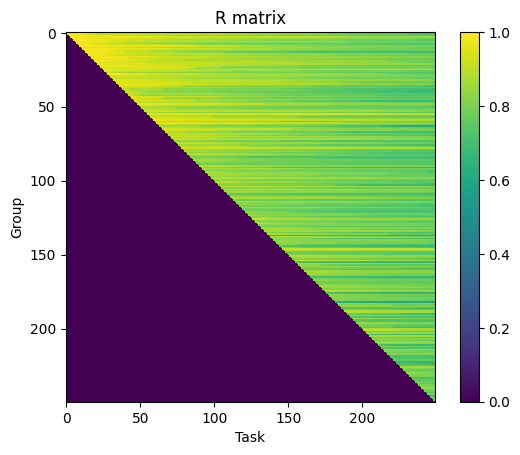

In [ ]:
# imshow

import matplotlib.pyplot as plt

plt.imshow(R, interpolation='nearest')
plt.colorbar()
plt.title('R matrix')
plt.xlabel('Task')
plt.ylabel('Group')
plt.show()

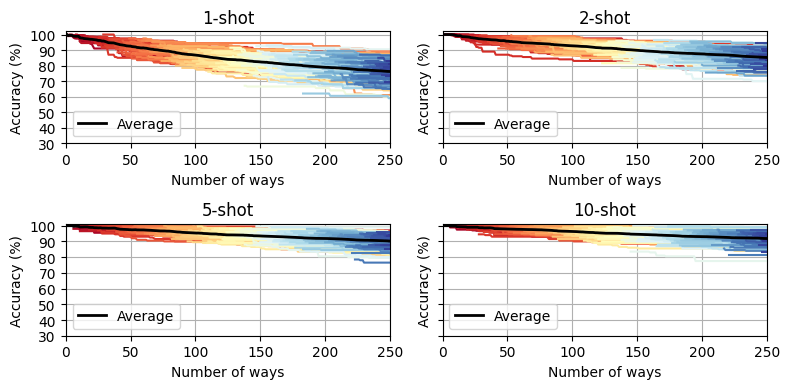

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# load preds_targets from pickle file



def plot_results(R_list: list[np.ndarray]) -> None:
    fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharey='row')
    axs = axs.flatten()

    for idx, (R, ax) in enumerate(zip(R_list, axs)):
        T = R.shape[0]
        cmap = plt.cm.RdYlBu # cool
        colors = [cmap((i + 1) / T) for i in range(T)]

        for i in range(T):
            ax.plot(range(i + 1, T + 1), R[i, :][i:] * 100, color=colors[i])

        avg_curve = np.sum(R, axis=0) / np.arange(1, T + 1)
        ax.plot(range(1,
                      len(avg_curve) + 1),
                avg_curve * 100,
                label="Average",
                color="black",
                linewidth=2)

        shotty = {0: 1, 1: 2, 2: 5, 3: 10}[idx]

        ax.set_title(f"{shotty}-shot")
        # if idx in [2, 3]:
        ax.set_xlabel("Number of ways")
        # if idx % 2 == 0:
        ax.set_ylabel("Accuracy (%)")
        ax.set_yticks(np.arange(30, 101, 10))
        # if idx in [0, 1]: # disable x tick labels
        # ax.set_xticklabels([])
        ax.set_xlim(0, 250)
        ax.grid(True)
        ax.legend(loc='lower left')

    fig.tight_layout()
    fig.savefig("omniglot_10_shot_forgetting_curves_2x2.pdf",
                bbox_inches='tight')
    plt.show()

plot_results([R1, R2, R3, R4])

In [ ]:
import pickle

# save [R1, R2, R3, R4] to pickle file vg3yq0yt

with open('vg3yq0yt_Rmatrices_1_2_5_10_shot.pkl', 'wb') as f:
    pickle.dump([R1, R2, R3, R4], f)